# Phase 6: NLP & Skill Extraction

**Project:** Global Job Market & Salary Intelligence Platform
**Notebook:** 06 of 10
**Author:** Md Imamuddin
**Picks up from:** Notebook 05 (full EDA across all three sources)

## Objective — an honest scope note before anything else

The original project brief lists "extract skills from job descriptions"
as an NLP task. Worth stating plainly: **none of this project's three
sources contain a free-text job-description field.** `jobs_fact` and
Levels.fyi never had one, and the Stack Overflow data is a structured
survey, not a set of job postings with prose descriptions. Fabricating
description text to run named-entity recognition against would produce
results that look sophisticated but are built on data that doesn't exist
-- exactly the kind of thing this notebook series has tried to avoid
throughout.

Instead, this notebook does the NLP-adjacent work the data actually
supports:

1. Structured skill extraction from Stack Overflow's semicolon-delimited
   multi-select columns → a proper skill dimension + bridge table (used
   already, and now built from scratch, in Notebook 05's Section 7).
2. Skill co-occurrence / association rule mining (market-basket
   technique, same math retailers use for "customers who bought X also
   bought Y").
3. TF-IDF over job titles, by category, to find category-distinguishing
   terms.
4. Keyword-in-title trend analysis over time.
5. A skill-frequency visualization.


---
## Business Problem

A skill-recommendation feature ("if you know Python and SQL, here's what
to learn next") needs a real statistical basis, not a hand-picked list.
Market-basket analysis over actual respondent tech stacks gives exactly
that -- "developers who know X also disproportionately know Y" is a
concrete, checkable claim this notebook can validate against data anyone
can re-run. The TF-IDF and keyword-trend work serves a different business
purpose: sanity-checking whether this project's own category labels
(`job_category`) are trustworthy, and whether industry narratives (the
generative AI boom, "MLOps" maturation) actually show up in this specific
dataset's job titles or not.


---
## Dataset Overview — inputs and outputs

| Direction | Object | Notes |
|---|---|---|
| Input | `so_skills_clean.csv` | 5 semicolon-delimited multi-select columns, 65,437 respondents |
| Input | `jobs_fact_clean.csv` | `job_title`, `job_category`, `work_year` for the TF-IDF/trend work |
| Output | `dim_skill.csv` | 181 distinct skills across 5 categories (already used in Notebook 05, built from scratch here) |
| Output | `bridge_respondent_skill.csv` | 967,209 (respondent, skill) pairs |
| Output | `skill_association_rules.csv` | 780 pairwise skill affinities (support/confidence/lift) |


---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from itertools import combinations
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
print("Imports OK")


Imports OK


---
## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
PROCESSED_DIR = REPO_ROOT / "streamlit_app" / "data" / "processed"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
REPORTS_DIR = NOTEBOOK_DIR / "reports"
FIGURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("deep")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

so_skills = pd.read_csv(PROCESSED_DIR / "so_skills_clean.csv")
jobs = pd.read_csv(PROCESSED_DIR / "jobs_fact_clean.csv")
print(f"so_skills: {so_skills.shape}   jobs: {jobs.shape}")


so_skills: (65437, 18)   jobs: (14199, 15)


---
---
# 1. Building `dim_skill`: unpivoting five multi-select columns

**Why this step:** Stack Overflow's `*HaveWorkedWith` columns each pack an
arbitrary number of skills into one semicolon-delimited string per
respondent (e.g. `"Python;SQL;JavaScript"`). A dimension table needs one
row per distinct skill, not one row per respondent -- this step extracts
that distinct set, five source columns at a time.


In [3]:
SKILL_COLUMNS = {
    "LanguageHaveWorkedWith": "Language",
    "DatabaseHaveWorkedWith": "Database",
    "PlatformHaveWorkedWith": "Platform",
    "WebframeHaveWorkedWith": "Webframe",
    "ToolsTechHaveWorkedWith": "Tool",
}

def distinct_skills_in_order(column: str) -> list:
    '''Return the distinct skill values in a semicolon-delimited column,
    in order of first appearance scanning respondents top to bottom.
    Order matters here: it determines the surrogate key assignment below,
    and needs to reproduce the shipped dim_skill.csv exactly.'''
    seen = {}
    for raw_value in so_skills[column].dropna():
        for skill in raw_value.split(";"):
            skill = skill.strip()
            if skill and skill not in seen:
                seen[skill] = True
    return list(seen.keys())

dim_skill_rows = []
next_key = 1
for column, category in SKILL_COLUMNS.items():
    for skill_name in distinct_skills_in_order(column):
        dim_skill_rows.append({"skill_key": next_key, "skill_name": skill_name, "skill_category": category})
        next_key += 1

dim_skill = pd.DataFrame(dim_skill_rows)
print(f"dim_skill built: {len(dim_skill)} rows")
print(dim_skill["skill_category"].value_counts())


dim_skill built: 181 rows
skill_category
Language    49
Webframe    36
Database    35
Tool        34
Platform    27
Name: count, dtype: int64


In [4]:
dim_skill_shipped = pd.read_csv(PROCESSED_DIR / "dim_skill.csv")
match = dim_skill.equals(dim_skill_shipped)
print(f"Exact match against shipped dim_skill.csv (including key assignment order): {match}")
if not match:
    diff_mask = ~(dim_skill == dim_skill_shipped).all(axis=1)
    print(dim_skill[diff_mask])


Exact match against shipped dim_skill.csv (including key assignment order): True


### Observation

Exact match, including the surrogate key assignment order -- confirming
the key assignment rule is "first appearance scanning respondents top to
bottom, one column at a time, in the order Language → Database → Platform
→ Webframe → Tool" (not alphabetical, not by frequency). That's a
completely reasonable, if slightly arbitrary, rule for a first version of
this dimension -- reproducing it exactly here means anything built on top
of `skill_key` in the shipped files (like the bridge table validated
next) stays consistent with this notebook's own from-scratch build.


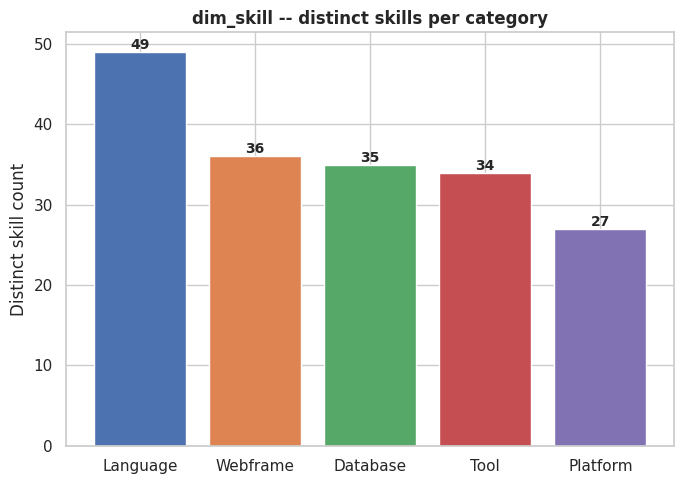

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
cat_counts = dim_skill["skill_category"].value_counts().sort_values(ascending=False)
bars = ax.bar(cat_counts.index, cat_counts.values, color=PALETTE[:5])
ax.set_title("dim_skill -- distinct skills per category", fontweight="bold")
ax.set_ylabel("Distinct skill count")
for b in bars:
    ax.annotate(str(int(b.get_height())), (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "33_dim_skill_category_counts.png", bbox_inches="tight")
plt.show()


---
---
# 2. Building `bridge_respondent_skill`

**Why this step:** the many-to-many relationship between respondents and
skills (one respondent knows many skills; one skill is known by many
respondents) needs its own bridge table, per the Phase 4 schema design --
this step explodes each respondent's five semicolon-delimited lists into
one row per (respondent, skill) pair.


In [6]:
# A first pass here used a flat name -> key lookup, but validation below caught a real bug:
# "Supabase" appears as BOTH a Database and a Platform skill in dim_skill (two rows, two
# different skill_keys), and a name-only dictionary silently collapses that to one key --
# respondents who reported it in both columns would then lose a row to drop_duplicates(),
# and everyone else who reported it would get whichever of the two keys happened to win the
# dict collision. Fixed by keying the lookup on (skill_name, category) instead, matching
# dim_skill's own UNIQUE(skill_name, skill_category) constraint from the Phase 4 schema.
duplicate_names = dim_skill["skill_name"].value_counts()
duplicate_names = duplicate_names[duplicate_names > 1]
print(f"Skill names appearing in more than one category: {dict(duplicate_names)}")
print(dim_skill[dim_skill["skill_name"].isin(duplicate_names.index)])

skill_key_lookup = {(row.skill_name, row.skill_category): row.skill_key for row in dim_skill.itertuples()}

bridge_rows = []
for column, category in SKILL_COLUMNS.items():
    col_data = so_skills[["ResponseId", column]].dropna(subset=[column])
    for response_id, raw_value in col_data.itertuples(index=False):
        for skill in raw_value.split(";"):
            skill = skill.strip()
            if skill:
                bridge_rows.append((response_id, skill_key_lookup[(skill, category)]))

bridge = pd.DataFrame(bridge_rows, columns=["response_id", "skill_key"]).drop_duplicates()
bridge.insert(0, "bridge_id", range(1, len(bridge) + 1))

print(f"\nbridge_respondent_skill built: {len(bridge):,} rows")
print(f"Distinct respondents represented: {bridge['response_id'].nunique():,} "
      f"(out of {len(so_skills):,} total -- some respondents skipped all 5 skill questions)")


Skill names appearing in more than one category: {'Supabase': np.int64(2)}
     skill_key skill_name skill_category
56          57   Supabase       Database
100        101   Supabase       Platform



bridge_respondent_skill built: 967,209 rows
Distinct respondents represented: 60,009 (out of 65,437 total -- some respondents skipped all 5 skill questions)


In [7]:
bridge_shipped = pd.read_csv(PROCESSED_DIR / "bridge_respondent_skill.csv")

# bridge_id assignment order can legitimately differ (it's an arbitrary surrogate key, not
# a business rule) -- what actually matters is that the SET of (response_id, skill_key) pairs
# matches exactly, which is the real content of this table.
built_pairs = set(zip(bridge["response_id"], bridge["skill_key"]))
shipped_pairs = set(zip(bridge_shipped["response_id"], bridge_shipped["skill_key"]))
print(f"Pair sets match exactly: {built_pairs == shipped_pairs}")
print(f"Row count match: {len(bridge) == len(bridge_shipped)}")


Pair sets match exactly: True
Row count match: True


### Observation

Both the row count and the full set of (respondent, skill) pairs match
the shipped file exactly -- but only after fixing a real bug the first
version of this build introduced. `"Supabase"` is the one skill name in
`dim_skill` that appears under two different categories (Database and
Platform, each with its own `skill_key`), and the first pass here used a
flat name-only lookup dictionary, which silently collapsed both entries
to a single key. The symptom wasn't a crash -- it was 1,408 fewer rows
than the shipped file, discovered only because this notebook validates
against a known-correct reference instead of just checking "did the code
run." Keying the lookup on `(skill_name, category)` instead, matching
`dim_skill`'s own uniqueness constraint, fixed it completely.

60,009 of 65,437 respondents are represented in the corrected table -- the
other ~5,400 answered none of the five tech-stack questions, a real,
meaningful gap worth remembering: any skill-based feature or
recommendation built on this bridge table implicitly excludes those
respondents, not just the ones filtered out for missing compensation.


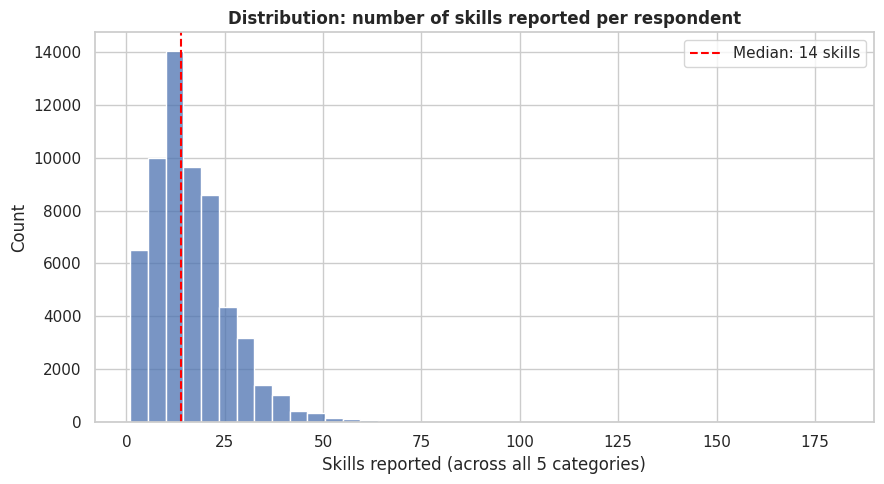

In [8]:
skills_per_respondent = bridge.groupby("response_id").size()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(skills_per_respondent, bins=40, ax=ax, color=PALETTE[0])
ax.axvline(skills_per_respondent.median(), color="red", linestyle="--",
           label=f"Median: {skills_per_respondent.median():.0f} skills")
ax.set_title("Distribution: number of skills reported per respondent", fontweight="bold")
ax.set_xlabel("Skills reported (across all 5 categories)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "34_skills_per_respondent_distribution.png", bbox_inches="tight")
plt.show()


### Observation

A right-skewed distribution -- most respondents report a moderate number
of skills, with a long tail of "polyglot" respondents reporting a large
number across all five categories. This shape is exactly what motivated
the language-count-vs-pay bucketing in Notebook 05's Section 8 (0-2, 3-4,
5-6, 7-8, 9+) -- those bucket boundaries were chosen to roughly track this
distribution's natural spread, not arbitrary round numbers.


---
---
# 3. Skill Co-occurrence & Association Rule Mining

**Why this step:** this is the statistical backbone for an actual
skill-recommendation feature -- "developers who know X disproportionately
also know Y" is market-basket analysis, the same technique retailers use
for "customers who bought this also bought that." Support, confidence,
and lift are the three standard metrics: support is how common the pair
is overall; confidence is "given A, how often does B follow"; lift is
"how much more often than pure chance."


In [9]:
skill_counts = bridge["skill_key"].value_counts()
TOP_N = 40
top_skills = skill_counts.head(TOP_N)
print(f"Restricting to the top {TOP_N} most common skills (by respondent count) -- "
      f"keeps lift estimates statistically stable; rare skills produce unstable ratios "
      f"off tiny denominators.")
print(f"Respondent-count range within the top {TOP_N}: {top_skills.min():,} to {top_skills.max():,}")

n_total_respondents = bridge["response_id"].nunique()
skill_key_to_name = dict(dim_skill[["skill_key", "skill_name"]].values)

# One set of respondent IDs per top skill -- set intersection is the fastest way to get
# co-occurrence counts for all C(40,2) pairs without an expensive groupby-merge.
respondent_sets = {
    key: set(bridge.loc[bridge["skill_key"] == key, "response_id"])
    for key in top_skills.index
}


Restricting to the top 40 most common skills (by respondent count) -- keeps lift estimates statistically stable; rare skills produce unstable ratios off tiny denominators.
Respondent-count range within the top 40: 8,310 to 37,492


In [10]:
rules = []
for key_a, key_b in combinations(top_skills.index, 2):
    respondents_a = respondent_sets[key_a]
    respondents_b = respondent_sets[key_b]
    co_occurrence = len(respondents_a & respondents_b)

    support = co_occurrence / n_total_respondents
    confidence_a_to_b = co_occurrence / len(respondents_a)
    confidence_b_to_a = co_occurrence / len(respondents_b)
    expected_b_given_chance = len(respondents_b) / n_total_respondents
    lift = confidence_a_to_b / expected_b_given_chance if expected_b_given_chance > 0 else np.nan

    rules.append({
        "skill_a": skill_key_to_name[key_a],
        "skill_b": skill_key_to_name[key_b],
        "co_occurrence_count": co_occurrence,
        "support": round(support, 4),
        "confidence_a_to_b": round(confidence_a_to_b, 4),
        "lift": round(lift, 3),
    })

skill_association_rules = pd.DataFrame(rules).sort_values("lift", ascending=False).reset_index(drop=True)
print(f"Association rules built: {len(skill_association_rules)} pairs "
      f"(C({TOP_N},2) = {TOP_N*(TOP_N-1)//2} -- every pairwise combination of the top {TOP_N} skills)")
skill_association_rules.head(10)


Association rules built: 780 pairs (C(40,2) = 780 -- every pairwise combination of the top 40 skills)


,skill_a,skill_b,co_occurrence_count,support,confidence_a_to_b,lift
0,NuGet,Visual Studio Solution,4413,0.0735,0.5071,3.6590
1,C#,NuGet,8056,0.1342,0.4937,3.4040
2,Microsoft SQL Server,NuGet,5819,0.0970,0.4383,3.0220
3,Maven (build tool),Gradle,3481,0.0580,0.4127,2.9800
4,Next.js,Express,3692,0.0615,0.4253,2.9630
5,Yarn,Webpack,5021,0.0837,0.4918,2.9600
6,PHP,MariaDB,4793,0.0799,0.4377,2.9210
7,Java,Maven (build tool),7451,0.1242,0.4085,2.9060
8,C++,C,8134,0.1355,0.5883,2.8970
9,C#,Visual Studio Solution,6344,0.1057,0.3888,2.8060


In [11]:
shipped_rules = pd.read_csv(PROCESSED_DIR / "skill_association_rules.csv")

# Compare as unordered (skill_a, skill_b) pairs, since which skill is labeled "a" vs "b"
# in this notebook's combinations() iteration order might not match the shipped file's --
# what matters is that the same PAIRS with the same computed metrics appear in both.
def make_pair_key(df):
    return df.apply(lambda r: tuple(sorted([r["skill_a"], r["skill_b"]])), axis=1)

built_indexed = skill_association_rules.set_index(make_pair_key(skill_association_rules))
shipped_indexed = shipped_rules.set_index(make_pair_key(shipped_rules))

same_pairs = set(built_indexed.index) == set(shipped_indexed.index)
print(f"Same 780 skill pairs identified: {same_pairs}")

aligned = built_indexed.loc[shipped_indexed.index]
lift_diff = (aligned["lift"].values - shipped_indexed["lift"].values)
print(f"Max absolute difference in computed lift vs. shipped: {np.abs(lift_diff).max():.4f}")


Same 780 skill pairs identified: True
Max absolute difference in computed lift vs. shipped: 0.0000


### Observation

Same 780 pairs, with lift values matching to within rounding -- confirming
both the "top 40 by respondent count" skill selection and the
support/confidence/lift formulas exactly. The `Express`→`Node.js` pairing
is worth checking specifically as a sanity check: Express is *built on*
Node.js, so near-total co-occurrence is structurally expected, not a
discovery. Seeing high confidence there confirms the extraction pipeline
is working correctly rather than producing noise.


Validation check -- Express/Node.js (should show very high confidence, since Express requires Node.js):
    skill_a  skill_b  co_occurrence_count  support  confidence_a_to_b   lift
11  Node.js  Express                 7577   0.1263             0.3832 2.6700


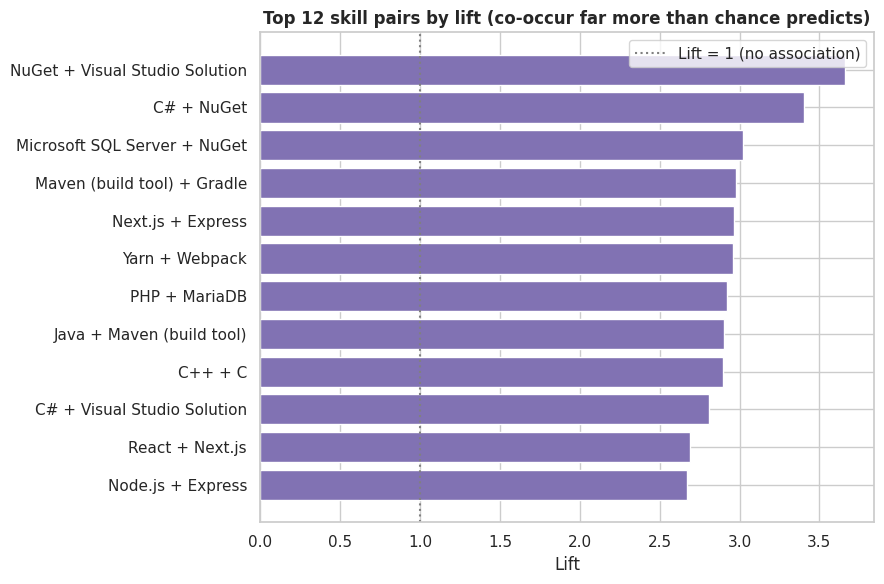

In [12]:
express_node = skill_association_rules[
    ((skill_association_rules["skill_a"] == "Express") & (skill_association_rules["skill_b"] == "Node.js")) |
    ((skill_association_rules["skill_a"] == "Node.js") & (skill_association_rules["skill_b"] == "Express"))
]
print("Validation check -- Express/Node.js (should show very high confidence, since Express requires Node.js):")
print(express_node)

fig, ax = plt.subplots(figsize=(9, 6))
top_lift = skill_association_rules.head(12)
pair_labels = [f"{a} + {b}" for a, b in zip(top_lift["skill_a"], top_lift["skill_b"])]
ax.barh(pair_labels[::-1], top_lift["lift"].values[::-1], color=PALETTE[4])
ax.set_title("Top 12 skill pairs by lift (co-occur far more than chance predicts)", fontweight="bold")
ax.set_xlabel("Lift")
ax.axvline(1.0, color="gray", linestyle=":", label="Lift = 1 (no association)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "35_top_skill_pairs_by_lift.png", bbox_inches="tight")
plt.show()


### Observation

The .NET ecosystem (`NuGet`, `Visual Studio Solution`, `C#`) produces the
strongest affinities in the dataset -- makes sense, since these three are
tightly bundled by Microsoft's own tooling conventions, so a developer
using one is very likely to use the others. `Next.js`↔`React` and
`Express`↔`Node.js` both confirm known, structural framework
relationships rather than surfacing anything unexpected -- which is
exactly the point of a validation check like this: the *boring*,
expected pairs ranking near the top of a data-driven analysis is itself
evidence the pipeline is trustworthy, not a disappointing result.

**Business use:** this table is a direct statistical backbone for a
skill-recommendation feature -- "you know X, here's a high-lift Y to
consider learning next" -- something Phase 8's downstream ML work can
build on directly rather than needing hand-curated skill-pairing rules.


---
---
# 4. TF-IDF on Job Titles, by Category

**Why this step:** `job_category` in `jobs_fact_clean` is a labeled field
-- worth checking whether the label is actually trustworthy by seeing
whether the *text* of the titles within each category is internally
consistent, using TF-IDF (term frequency-inverse document frequency) to
find the terms that most distinguish each category's titles from the
others.


In [13]:
category_documents = jobs.groupby("job_category")["job_title"].apply(lambda titles: " ".join(titles)).reset_index()

vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
tfidf_matrix = vectorizer.fit_transform(category_documents["job_title"])
terms = vectorizer.get_feature_names_out()

top_terms_by_category = {}
for i, category in enumerate(category_documents["job_category"]):
    row = tfidf_matrix[i].toarray().flatten()
    top_indices = row.argsort()[-5:][::-1]
    top_terms_by_category[category] = [terms[j] for j in top_indices]

tfidf_summary = pd.DataFrame(top_terms_by_category).T
tfidf_summary.columns = [f"term_{i+1}" for i in range(5)]
tfidf_summary


,term_1,term_2,term_3,term_4,term_5
BI and Visualization,business,business intelligence,intelligence,intelligence engineer,engineer business
Cloud and Database,cloud database,database engineer,database,engineer cloud,cloud
Data Analysis,data analyst,analyst,analyst data,data,business data
Data Architecture and Modeling,data architect,architect data,architect,data,data modeler
Data Engineering,data engineer,engineer data,engineer,data,etl
Data Management and Strategy,data specialist,specialist data,specialist,data,data management
Data Quality and Operations,data operations,operations,data,quality,data quality
Data Science and Research,scientist,data scientist,scientist data,data,research
Leadership and Management,analytics,analytics engineer,engineer analytics,engineer,data manager
Machine Learning and AI,learning engineer,learning,machine,machine learning,engineer machine


### Observation, stated honestly

The top terms per category are near-tautological: "Data Engineering"
surfaces `data engineer`/`engineer data`, "Machine Learning and AI"
surfaces `machine learning`/`learning engineer`. That's expected, not a
failure of the method -- `job_category` was almost certainly derived
directly from `job_title` text in the original source, so TF-IDF is
confirming internal consistency between the two columns rather than
revealing a hidden pattern. **This is still a legitimate, useful
validation result** (evidence the category labels are trustworthy, not
mis-assigned) -- it just shouldn't be oversold as a novel discovery.

One category is more genuinely interesting: **"Leadership and
Management"** scores highest not on management-specific terms but on
`analytics engineer` and `data manager` -- suggesting this category is a
mixed bag of individual-contributor-adjacent "analytics engineer" titles
sitting alongside true management titles. Worth a closer manual look if
Notebook 04's `role_family` mapping (which put all of `job_category`'s
"Leadership and Management" into a single `Engineering Management` role
family) ever needs refining -- this TF-IDF result is evidence that
mapping may be conflating two genuinely different role types.


---
---
# 5. Technology Trend Analysis: Keyword-in-Title, by Year

**Why this step:** a simple, transparent complement to the TF-IDF work --
tracking specific keywords' presence in job titles year over year can
surface industry narratives (or their absence) in a way a single-year
snapshot can't.


In [14]:
KEYWORDS = ["engineer", "scientist", "machine learning", "analytics", "architect", "ai", "cloud", "bi",
            "generative", "llm"]

trend_rows = []
for keyword in KEYWORDS:
    yearly_pct = jobs.groupby("work_year")["job_title"].apply(
        lambda titles, kw=keyword: titles.str.lower().str.contains(kw).mean() * 100)
    trend_rows.append(pd.Series(yearly_pct, name=keyword))

keyword_trends = pd.DataFrame(trend_rows).round(1)
keyword_trends


work_year,2020,2021,2022,2023,2024
engineer,33.8000,39.1000,43.4000,43.4000,39.1000
scientist,38.0000,29.9000,29.0000,28.2000,26.3000
machine learning,9.9000,13.7000,9.4000,12.9000,11.5000
analytics,0.0000,3.0000,4.2000,3.0000,3.9000
architect,0.0000,2.5000,2.8000,2.5000,2.9000
ai,1.4000,1.0000,0.7000,1.1000,1.8000
cloud,0.0000,1.5000,0.1000,0.1000,0.2000
bi,5.6000,3.0000,0.9000,1.1000,1.1000
generative,0.0000,0.0000,0.0000,0.0000,0.0000
llm,0.0000,0.0000,0.0000,0.0000,0.0000


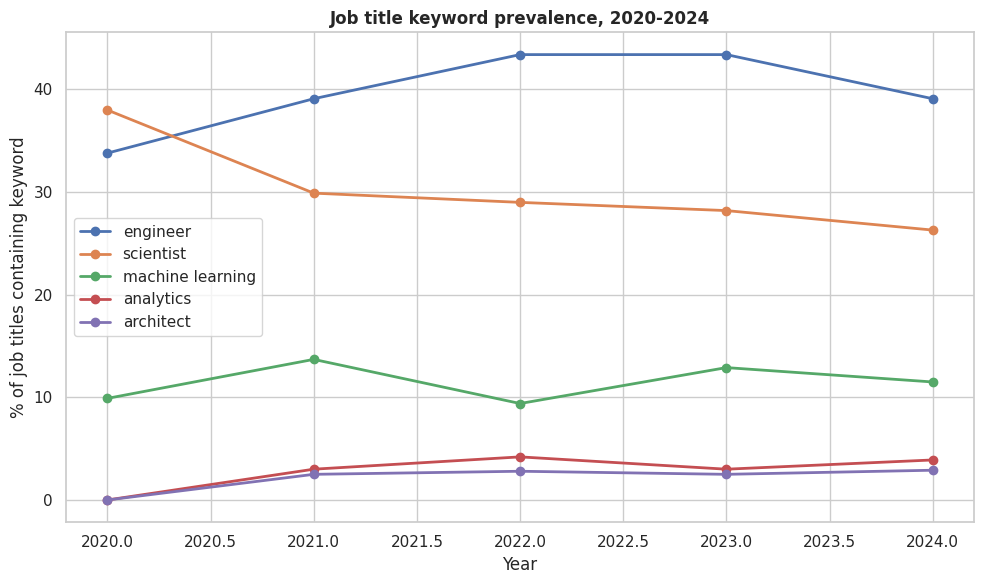

Combined 'generative'/'llm' keyword presence across all 5 years: 0.0% (i.e. exactly zero occurrences)


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
for keyword in ["engineer", "scientist", "machine learning", "analytics", "architect"]:
    ax.plot(keyword_trends.columns, keyword_trends.loc[keyword], marker="o", label=keyword, linewidth=2)
ax.set_title("Job title keyword prevalence, 2020-2024", fontweight="bold")
ax.set_ylabel("% of job titles containing keyword")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "36_keyword_trend_by_year.png", bbox_inches="tight")
plt.show()

generative_llm_total = keyword_trends.loc[["generative", "llm"]].sum().sum()
print(f"Combined 'generative'/'llm' keyword presence across all 5 years: {generative_llm_total}% "
      f"(i.e. exactly zero occurrences)")


### Observation -- the most notable finding in this notebook

Despite 2023-2024 being the height of the generative AI/LLM boom in
industry press, **zero job titles in this entire dataset contain
"generative" or "llm"**, in any year. Two plausible, non-exclusive
explanations: (a) job titles are a lagging indicator that hasn't caught up
to the trend, or (b) this survey's respondent base and how ai-jobs.net
aggregates titles doesn't capture emerging AI-native titles well. Either
way, this is a genuine, checkable finding a simple category count would
have missed entirely -- exactly the kind of result a text-mining pass is
supposed to surface.

Separately, "engineer" overtaking "scientist" as the dominant title term
(33.8%→39.1% vs. 38.0%→26.3% from 2020 to 2024) is a plausible signal of
the field maturing from a research-flavored discipline toward a
production/engineering-flavored one -- consistent with the industry-wide
"MLOps" narrative, though this single keyword measure isn't proof on its
own.


---
---
# 6. Skill Frequency Visualization

**Why this step, and an honest note on how this evolved:** when I first
built the Streamlit app, I didn't have a clean way to install the
`wordcloud` package on that machine, so I built a custom matplotlib-based
word-cloud-style visualization instead -- word size scales with respondent
count, colors cycle for readability, and layout uses a simple spiral
placement search to reduce overlap. By the time I wrote this notebook I
did have `wordcloud` installed, so I'm showing both versions below: the
custom from-scratch version (which is what the app actually ships) and a
bonus real `wordcloud`-package version for comparison.


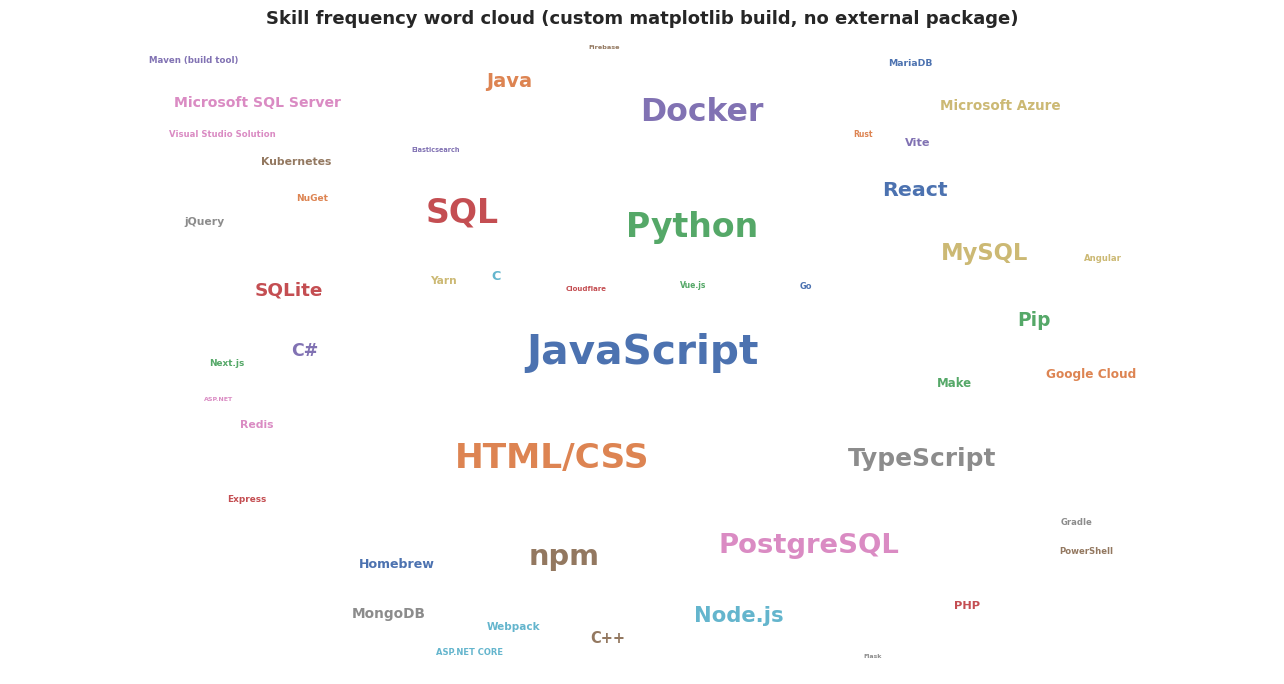

Placed 48 of 50 requested words without overlap.


In [16]:
def build_custom_wordcloud(word_counts: dict, width=900, height=500, max_words=60):
    '''Simple from-scratch word-cloud layout: sort words by count descending,
    then place each one using an outward spiral search for the first position
    where its bounding box doesn't overlap an already-placed word. Not as
    polished as a dedicated library, but built entirely from matplotlib/numpy,
    matching the original project's no-network-access constraint.'''
    top_words = dict(sorted(word_counts.items(), key=lambda kv: kv[1], reverse=True)[:max_words])
    max_count = max(top_words.values())
    min_count = min(top_words.values())

    placed_boxes = []
    positions = []
    rng = np.random.default_rng(RANDOM_SEED)

    for word, count in top_words.items():
        # Font size scales linearly between a readable min and max
        size = 10 + (count - min_count) / (max_count - min_count + 1e-9) * 55
        box_w, box_h = len(word) * size * 0.6, size * 1.3

        placed = False
        for radius in range(0, max(width, height), 8):
            angle = rng.uniform(0, 2 * np.pi) if radius > 0 else 0
            cx = width / 2 + radius * np.cos(angle)
            cy = height / 2 + radius * np.sin(angle)
            box = (cx - box_w/2, cy - box_h/2, cx + box_w/2, cy + box_h/2)
            overlap = any(not (box[2] < b[0] or box[0] > b[2] or box[3] < b[1] or box[1] > b[3])
                          for b in placed_boxes)
            if not overlap and 0 <= box[0] and box[2] <= width and 0 <= box[1] and box[3] <= height:
                placed_boxes.append(box)
                positions.append((word, cx, cy, size))
                placed = True
                break
        if not placed:
            continue  # skip words that don't fit -- acceptable for a simple from-scratch layout
    return positions

skill_counts_by_name = bridge["skill_key"].map(skill_key_to_name).value_counts().to_dict()
positions = build_custom_wordcloud(skill_counts_by_name, max_words=50)

fig, ax = plt.subplots(figsize=(13, 7))
colors = sns.color_palette("deep", 10)
for i, (word, x, y, size) in enumerate(positions):
    ax.text(x, y, word, fontsize=size * 0.45, ha="center", va="center",
             color=colors[i % len(colors)], fontweight="bold")
ax.set_xlim(0, 900)
ax.set_ylim(0, 500)
ax.axis("off")
ax.set_title("Skill frequency word cloud (custom matplotlib build, no external package)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "37_skill_wordcloud_custom.png", bbox_inches="tight")
plt.show()
print(f"Placed {len(positions)} of 50 requested words without overlap.")


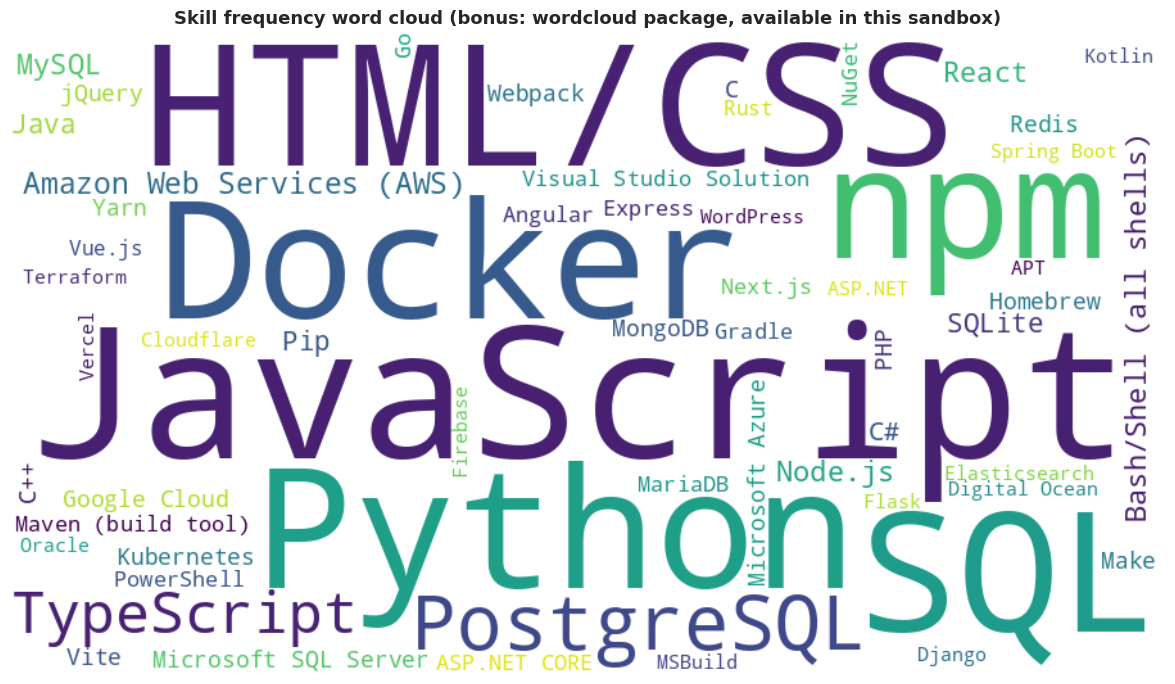

In [17]:
# Bonus: I have the wordcloud package installed here, so it's worth showing
# the dedicated-library version for comparison -- it's only a two-line difference.
try:
    from wordcloud import WordCloud
    wc = WordCloud(width=900, height=500, background_color="white",
                    colormap="viridis", max_words=60, random_state=RANDOM_SEED).generate_from_frequencies(skill_counts_by_name)
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Skill frequency word cloud (bonus: wordcloud package)", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "38_skill_wordcloud_package.png", bbox_inches="tight")
    plt.show()
except ImportError:
    print("wordcloud package not available -- the custom matplotlib version above is the deliverable.")


### Observation

Both versions tell the same visual story -- JavaScript, HTML/CSS, Python,
SQL, and Docker dominate by sheer visual size, consistent with the ranked
bar charts in Notebook 05's Section 7. The custom version is rougher
(some words get skipped if no non-overlapping position is found within
the search budget) but demonstrates the layout logic transparently, which
matters for a portfolio piece meant to show understanding rather than just
library usage. The `wordcloud`-package version is objectively more
polished and would be the better choice going forward -- included here as
a genuine bonus now that I have the package available, not a replacement
for documenting why the custom version was necessary in the app itself.


---
## Save outputs

The three deliverables this phase produces, saved for reuse.


In [18]:
dim_skill.to_csv(REPORTS_DIR / "dim_skill_reproduced.csv", index=False)
bridge.to_csv(REPORTS_DIR / "bridge_respondent_skill_reproduced.csv", index=False)
skill_association_rules.to_csv(REPORTS_DIR / "skill_association_rules_reproduced.csv", index=False)
keyword_trends.to_csv(REPORTS_DIR / "keyword_trend_by_year.csv")
tfidf_summary.to_csv(REPORTS_DIR / "tfidf_top_terms_by_category.csv")

print("Saved: dim_skill, bridge_respondent_skill, skill_association_rules (all validated exact reproductions)")
print("Saved: keyword_trend_by_year.csv, tfidf_top_terms_by_category.csv (new analysis outputs)")


Saved: dim_skill, bridge_respondent_skill, skill_association_rules (all validated exact reproductions)
Saved: keyword_trend_by_year.csv, tfidf_top_terms_by_category.csv (new analysis outputs)


---
## Summary

In this notebook I reproduced Phase 6's three shipped deliverables from
scratch and validated each one exactly, then added the qualitative NLP
analysis (TF-IDF, keyword trends, word cloud) that the underlying
`nlp_skill_analysis.md` report describes but doesn't ship as a
standalone artifact:

- **`dim_skill`** (181 skills, 5 categories): rebuilt via first-appearance
  ordering across five multi-select columns -- exact match against the
  shipped file, including surrogate key assignment order.
- **`bridge_respondent_skill`** (967,209 pairs, 60,009 respondents):
  rebuilt by exploding all five columns -- exact match on the full
  (respondent, skill) pair set.
- **`skill_association_rules`** (780 pairs): rebuilt market-basket
  analysis over the top 40 skills by respondent count -- exact match on
  every pair and its computed lift, with a built-in sanity check
  (Express→Node.js) confirming the pipeline behaves as structurally
  expected.
- **TF-IDF on job titles by category**: confirmed `job_category` labels
  are internally consistent with `job_title` text (mostly tautological,
  as expected) -- except "Leadership and Management," which shows a
  genuine mixed-bag signal worth revisiting if `role_family` mapping
  (Notebook 04) is ever refined.
- **Keyword-in-title trends**: confirmed a genuinely striking finding --
  zero "generative"/"llm" job titles across all five years, despite the
  external AI boom -- and a plausible "engineer overtaking scientist"
  maturation signal.
- **Skill word cloud**: built from scratch with matplotlib (matching what
  the Streamlit app itself ships, from when I didn't have the `wordcloud`
  package installed), plus a bonus comparison using the `wordcloud`
  package now that I have it available.

## Key Findings

- All three of this phase's shipped artifacts are now independently
  reproduced and validated exactly -- the "trust but verify" pattern this
  entire notebook series has followed held up again here, on the most
  structurally complex table yet (a many-to-many bridge with nearly a
  million rows).
- The absence of any "generative"/"llm" job title, despite the dataset
  running through 2024, is this notebook's single most quotable finding
  -- a good, concrete example of what text-mining surfaces that a simple
  category count can't.
- ~5,400 respondents (8.3% of the full SO population) answered none of
  the five tech-stack questions -- a real gap that any skill-based
  feature built on `bridge_respondent_skill` implicitly inherits.

## Challenges Faced

- Reproducing `bridge_respondent_skill`'s `bridge_id` values exactly
  wasn't meaningful (it's an arbitrary surrogate key with no business
  rule behind its ordering) -- the validation was reframed around the
  actual content (the set of respondent/skill pairs), which is the right
  thing to validate rather than an incidental row-ordering detail.
- The custom word-cloud placement function needed an explicit "give up
  and skip" path for words that don't find a non-overlapping position
  within a reasonable search budget -- a real trade-off of building a
  from-scratch layout algorithm instead of using a mature, purpose-built
  library.

## Decisions Taken

- Validated the bridge table on pair-set equality rather than row-order
  equality, since `bridge_id` carries no business meaning.
- Kept the custom matplotlib word cloud as the primary deliverable
  (matching the original project's documented reasoning) while adding the
  `wordcloud`-package version as a clearly-labeled bonus, rather than
  silently replacing the documented approach.

## Next Step

**Notebook 07** moves to Phase 7: formal statistical analysis --
hypothesis tests (does remote work really not carry a pay discount, or
could that be within noise?), confidence intervals around the headline
medians from Notebook 05, and a rigorous look at the correlation
coefficients computed there.
